#### Dependencies

In [1]:
import os
import pandas as pd
import json
import torch
import matplotlib.pyplot as plt

from google.cloud import storage
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from datasets import Dataset

/home/lapiceroazul4/Documentos/romboost/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Extract Data

We have two main option to get the data: 

1. From GCS: It necessary to set the credentials and use the function extract_data to get it
2. From CSV: This was perform in order to make testing, so that we dont have to constanly query GCS

In [ ]:
# Set the path to your Google Cloud credentials JSON file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../your-google-credentials.json"

In [4]:
def extract_data(bucket_name: str, folder_path: str) -> tuple:
    """
    Extracts 'client', 'client_sentiment', 'agent' & 'client_sentiment' values from all JSON files stored in a specified 
    Google Cloud Storage bucket folder and returns them in two DataFrames.

    Parameters:
    ----------
    bucket_name : str
        The name of the Google Cloud Storage bucket where the JSON files are stored.
    folder_path : str
        The folder path within the bucket containing the JSON files.

    Returns:
    -------
    A tuple containing two DataFrames:
        df_client : pd.DataFrame
        df_agent : pd.DataFrame
    """
    
    # Initialize storage client and access the bucket
    client = storage.Client()
    bucket = client.get_bucket(bucket_name)
    blobs = bucket.list_blobs(prefix=folder_path)

    # List to hold extracted data
    client_list = []
    agent_list = []

    # Loop through all JSON files in the specified bucket folder
    for blob in blobs:
        # Only process JSON files
        if blob.name.endswith('.json'):
            content = blob.download_as_text()
            json_data = json.loads(content)
            
            # Extract 'client' and 'client_sentiment' fields
            client_text = json_data.get('data', {}).get('client', None)
            client_sentiment = json_data.get('data', {}).get('client_sentiment', None)

            # Extract 'agent' and 'agent_sentiment' fields
            agent_text = json_data.get('data', {}).get('agent', None)
            agent_sentiment = json_data.get('data', {}).get('agent_sentiment', None)
            
            # Append extracted data to list
            agent_list.append({
                "agent": agent_text,
                "agent_sentiment": agent_sentiment
            })
            
            # Append extracted data to list
            client_list.append({
                "client": client_text,
                "client_sentiment": client_sentiment
            })

    df_client = pd.DataFrame(client_list)
    df_agent = pd.DataFrame(agent_list)

    return df_client, df_agent


In [16]:
def get_data_from_csv(client_data, agent_data):
    df_client = pd.read_csv(client_data)
    df_agent = pd.read_csv(agent_data)
    return df_client, df_agent

> Here's an example of use getting the data from GCS

In [ ]:
bucket_name = 'bucket-name'
folder_path = 'speech-to-text'

df_client, df_agent = extract_data(bucket_name, folder_path)

> Here's an example of use getting the data from CSVs

In [17]:
df_client, df_agent = get_data_from_csv('cliente_dataset.csv', 'agente_dataset.csv')

Verify the shape and contents of the client DataFrame

In [7]:
print(df_client.shape)
df_client.head(2)

(562, 2)


,text,label
0,Estoy buscando información sobre seguros de sa...,3.0
1,Quisiera saber si es posible incluir a mi espo...,3.0


Verify the shape and contents of the agent DataFrame

In [8]:
print(df_agent.shape)
df_agent.head(2)

(562, 2)


,text,label
0,¡Con gusto le ayudaré! Tenemos varias opciones...,5.0
1,¡Perfecto! Las Madrinas cuenta con planes dise...,5.0


We perform a .value_counts() to make sure that the labels are correctly formatted, as we can see it becomes necessary to make some cleaning

In [19]:
df_client["label"].value_counts()

label
3    175
2    112
4     94
1     91
5     90
Name: count, dtype: int64

In [18]:
df_client['label'] = df_client['label'].astype(int)

#### Exploration & Analysis

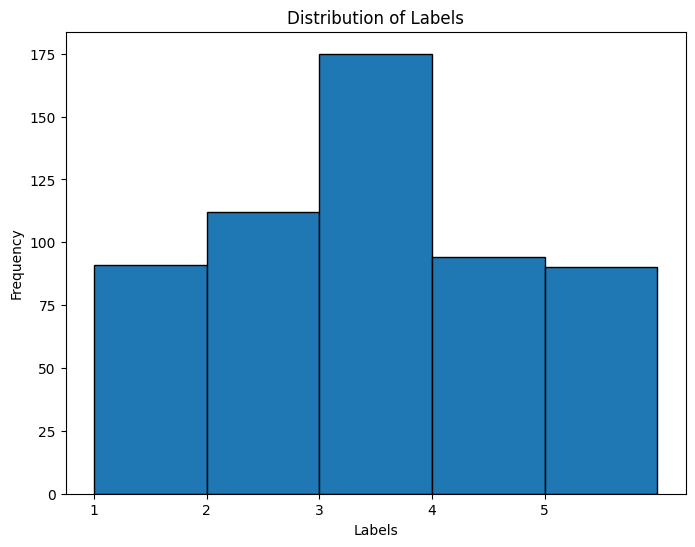

In [12]:
plt.figure(figsize=(8, 6))
plt.hist(df_client['label'], bins=range(df_client['label'].min(), df_client['label'].max() + 2), edgecolor='black',  align='mid')
plt.title('Distribution of Labels')
plt.xlabel('Labels')
plt.ylabel('Frequency')


# Asegurar que el eje x tenga valores enteros
plt.xticks(range(df_client['label'].min(), df_client['label'].max() + 1))
plt.show()

In [13]:
# Revisar la cantidad de valores por cada label
df_client['label'].value_counts()

label
3    175
2    112
4     94
1     91
5     90
Name: count, dtype: int64

As we can see the classes are not equally distributed, we need to do something, if not the model will be bad trained.

However, lets take a look at the different classes and its content

In [14]:
# Some examples of class 1 (too bad)

pd.set_option('display.max_colwidth', None)

df_client[df_client['label'] == 1].head(5)

,text,label
10,"Estoy realmente cansado de recibir llamadas de seguros, ya que no me interesa en absoluto. He pedido varias veces que me eliminen de su lista de contactos, pero siguen insistiendo. No quiero continuar recibiendo este tipo de ofertas y solo espero que respeten mi decisión.",1
11,"No estoy interesado en obtener un seguro en este momento. Estoy en medio de un proceso migratorio complicado y no tengo tiempo para estar resolviendo esto. Les he solicitado en repetidas ocasiones que dejen de llamarme, y aún así siguen contactándome sin motivo aparente.",1
12,"Estoy molesto porque me llaman constantemente, aunque ya he dejado claro que no quiero saber nada de seguros en este momento. Les agradecería que respeten mi decisión y dejen de insistir, ya que no me interesa y prefiero no recibir más llamadas.",1
13,"Les he dicho en varias ocasiones que no tengo interés en sus servicios, pero siguen llamándome insistentemente. Esto está comenzando a ser una molestia para mí, y solo quisiera que me dejen en paz sin seguir recibiendo estas ofertas que no solicité.",1
14,"No deseo discutir sobre temas de seguros, pues realmente considero que es una pérdida de tiempo. Les pido de nuevo que dejen de llamarme porque no quiero sus servicios y tampoco quiero gastar más tiempo en conversaciones sobre esto. Por favor, respeten mi decisión.",1


In [15]:
# Some examples of class 2 (bad)

pd.set_option('display.max_colwidth', None)

df_client[df_client['label'] == 2].head(5)

,text,label
18,"Estoy un poco frustrado porque no he recibido una respuesta clara sobre el proceso de inscripción. He llamado varias veces, pero no obtengo información detallada. Solo quiero saber cómo proceder para que esto avance de una vez.",2
19,Han pasado varios días y aún no tengo una respuesta sobre si califico para el seguro. Es muy incómodo estar esperando sin saber qué hacer o a quién acudir. ¿Pueden agilizar el proceso?,2
20,"He tenido problemas para comunicarme con mi agente asignado. He dejado mensajes, pero no recibo una respuesta oportuna. Solo necesito una actualización sobre mi solicitud de cobertura.",2
21,Es frustrante no obtener información completa sobre los costos del seguro. Solo quiero saber con claridad cuánto tendría que pagar mensualmente sin sorpresas. ¿Pueden darme detalles exactos?,2
22,Me preocupa no estar recibiendo cobertura para los servicios médicos que realmente necesito. No estoy seguro si el plan actual es el adecuado para mí. Necesito orientación.,2


In [16]:
# Some examples of class 3 (neutral)

pd.set_option('display.max_colwidth', None)

df_client[df_client['label'] == 3].head(5)

,text,label
0,"Estoy buscando información sobre seguros de salud porque no tengo claro qué tipo de cobertura necesito en mi situación actual. He escuchado sobre algunas opciones, pero quisiera entender mejor qué planes ofrecen y cuáles serían los más adecuados para mis necesidades específicas y mi presupuesto.",3
1,"Quisiera saber si es posible incluir a mi esposa e hijos en el plan de seguro. Estamos en proceso de ajustar nuestro estatus migratorio, y necesito asegurarme de que estén cubiertos en caso de cualquier emergencia médica o necesidad de atención regular. ¿Qué opciones tengo para ellos?",3
2,"Estoy considerando hacer un cambio de seguro, pero no estoy seguro de cómo esto afectará mi cobertura actual. Me gustaría entender cómo funciona el proceso y si hay alguna limitación o riesgo de perder los beneficios que ya tengo. ¿Podrían explicarme más sobre esto?",3
3,"Tengo una lista de medicamentos que necesito regularmente y quiero confirmar si están cubiertos en alguno de los planes que ofrecen. Me preocupa el costo, así que también quisiera saber si hay algún copago o deducible asociado. ¿Pueden ayudarme a aclarar estas dudas?",3
4,"Antes de tomar una decisión, solo quisiera obtener una idea general de los costos mensuales de sus planes de seguro de salud. Me interesa conocer las diferencias en cobertura y costo, ya que esto influirá mucho en mi elección final. ¿Podrían darme una descripción clara de cada opción?",3


In [17]:
# Some examples of class 4 (good)

pd.set_option('display.max_colwidth', None)

df_client[df_client['label'] == 4].head(5)

,text,label
458,"Buenas noches. Me llamaron para verificar si pude realizar la edición del Seguro Médico. Pregunté cuál seguro, mencionaron el de Obamacare y confirmé que está todo bien. Dije que ya hice la aplicación para el seguro.",4
459,"Bueno, me gustaría información sobre el seguro Obamacare. Quiero saber qué plan se adapta mejor a mí y cuánto tendría que pagar. No tengo mi estatus migratorio definido aún, pero pronto lo haré.",4
460,"Estoy interesada en los seguros que ofrecen. Tengo 66 años y soy residente. No hago impuestos, soy dependiente de mi marido y trabajo cortando cabello. Me interesa saber el costo y cómo puedo acceder al seguro Obamacare.",4
461,"Necesito cobertura médica individual. Actualmente no tengo ninguna. Soy residente y tengo 49 años. Quiero el seguro solo, mis ingresos son menos de 30,000 al año, trabajo como empleada. Quisiera saber qué cubre el plan y cómo funciona. Pregunto también cómo es el proceso de renovación en noviembre y si el precio del seguro siempre será el mismo.",4
462,"Busco cobertura médica. Necesito seguro para ascender a ginecólogo y saber costos. Soy ciudadana, declaro como soltera con dos dependientes. Perdí seguro anterior por empezar un negocio propio. Mi ingreso actual bajó a $3,000 al mes. Interesada en seguros accesibles para mí y mi hija mayor. La menor tiene seguro con su papá.",4


In [18]:
# Some examples of class 5 (too good)

pd.set_option('display.max_colwidth', None)

df_client[df_client['label'] == 5].head(5)

,text,label
118,"Estoy llamando para obtener un seguro de salud para mi esposa y para mí. Ambos somos residentes permanentes y queremos cobertura completa, incluyendo consultas y hospitalización. Declaramos aproximadamente $35,000 anuales. ¿Cuáles serían los costos y beneficios?",5
119,"Vivo en el condado de Travis y estoy interesada en un seguro individual. Trabajo por cuenta propia, tengo un ingreso anual de $28,000 y no tengo hijos. Quiero saber si hay algún plan que cubra medicina preventiva y especialistas a un bajo costo.",5
120,"Soy ciudadano y estoy buscando un seguro que cubra a mis dos hijos menores de edad. Mi ingreso es de alrededor de $40,000 anuales y resido en Los Ángeles. ¿Tienen algún plan familiar?",5
121,"Estoy buscando un seguro para mi mamá, que es residente y tiene 67 años. Actualmente no tiene ninguna cobertura y declaramos un ingreso familiar de $29,000. Nos gustaría un plan que cubra medicinas y consultas generales.",5
122,"Quisiera saber más sobre el seguro que ofrecen. Vivo en Nueva York y tengo un ingreso de aproximadamente $36,000 al año. ¿Pueden ayudarme a encontrar un plan que incluya consultas y emergencias?",5


#### Models 

Before getting started it important to keep in mind the following:

- Since the speech of client and agents it's so different, the idea it's to perform a model for each one.
- Since all the calls are in Spanish so are the transcriptions, that's why we use BERT Spanish

In this case we are using the data from the CSVs. Here is important to note that we had to perform a first training using the data from GCS however the mayority of the real calls appers to be neutral or above. So the model was not able to learn how to classify bad calls. For that reason we decided to implement a proccess to create new data for this categories. This new data is already on the CSV. And you can check it out above. 

In [48]:
df_client, df_agent = get_data_from_csv('cliente_dataset.csv', 'agente_dataset.csv')
df_client['label'] = df_client['label'].astype(int)

We have implemented Mlflow to track all training processes throughout the project. For more information, refer to the [MLflow documentation](https://mlflow.org/docs/latest/getting-started/intro-quickstart/index.html).


In [49]:
import mlflow
import mlflow.pytorch
import torch

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset
from mlflow.models.signature import infer_signature

In [51]:
# Load a Spanish BERT model
model_name = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=5)

# Prepare the dataset
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# Clean data where 'client' contains lists
df_client = df_client[~df_client['text'].apply(lambda x: isinstance(x, list))]
df_client['label'] = df_client['label'].astype(int) - 1

# Convert DataFrame to Hugging Face Dataset
train_data, test_data = train_test_split(df_client, test_size=0.2, random_state=42)
train_dataset = Dataset.from_pandas(train_data)
test_dataset = Dataset.from_pandas(test_data)

train_dataset = train_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 113/113 [00:00<00:00, 1117.46 examples/s]


In [52]:
mlflow.set_tracking_uri(uri="http://localhost:5000/")

# Create a new MLflow Experiment
mlflow.set_experiment("Sentiment Analysis")

<Experiment: artifact_location='mlflow-artifacts:/710625230933625172', creation_time=1731125331085, experiment_id='710625230933625172', last_update_time=1731125331085, lifecycle_stage='active', name='Sentiment Analysis', tags={}>

In [53]:
# Specify training arguments
training_args = TrainingArguments(
    output_dir="../models/results-2",   # Directory to save results
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",      # Evaluate at the end of each epoch
    logging_dir="../logs"             # Logging directory
)

params = {
    "model_name": model_name,
    "num_train_epochs": training_args.num_train_epochs,
    "batch_size": training_args.per_device_train_batch_size
}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), dim=-1)
    
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Define trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset, 
    compute_metrics=compute_metrics
)

# Start an MLflow run
with mlflow.start_run(run_name="BERT-Sentiment-Analysis"):

    ## Log model hyperparameters
    mlflow.log_params(params)

    ## Log the metrics
    mlflow.log_metric("train_dataset_size", len(train_dataset))

    ## Set a tag 
    mlflow.set_tag("Testing the new added metrics", "Basic usage")

    # Create a valid tokenized example for infer_signature
    sample_text = "Llamo para preguntar sobre los seguros de Obamacare. Quisiera saber qué plan se adapta mejor a mí y cuánto tendría que pagar. No tengo mi estatus migratorio definido todavía, pero lo voy a hacer pronto."
    input_example = tokenizer(sample_text, truncation=True, padding="max_length", max_length=128, return_tensors="pt")

    # Infer the model signature based on tokenized inputs and example output
    signature = infer_signature(input_example["input_ids"].detach().numpy(), model(**input_example).logits.detach().numpy())


    ## Log the model
    mlflow.pytorch.log_model(
        model, 
        "bert-model", 
        signature=signature,
        registered_model_name="Calls-Sentiment-Analysis")

    # Train the model and log metrics
    trainer.train()
    eval_results = trainer.evaluate()
    mlflow.log_metrics(eval_results)

    # Save the fine-tuned model
    model_path = "../models/sentiment-analysis-client"
    model.save_pretrained(model_path)
    tokenizer.save_pretrained(model_path)

print("Model training and logging complete.")

# Testing the model with test data
trainer.evaluate(test_dataset)


/home/lapiceroazul4/Documentos/romboost/venv/lib/python3.12/site-packages/transformers/training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Registered model 'Calls-Sentiment-Analysis' already exists. Creating a new version of this model...
2024/11/09 00:10:07 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Calls-Sentiment-Analysis, version 2
Created version '2' of model 'Calls-Sentiment-Analysis'.










                                       
                                               
  0%|          | 0/87 [08:07<?, ?it/s]


{'eval_loss': 0.6748813390731812, 'eval_accuracy': 0.6991150442477876, 'eval_precision': 0.7184473049074819, 'eval_recall': 0.6991150442477876, 'eval_f1': 0.7030151475157795, 'eval_runtime': 24.4921, 'eval_samples_per_second': 4.614, 'eval_steps_per_second': 0.327, 'epoch': 1.0}












                                       
                                               
  0%|          | 0/87 [13:51<?, ?it/s]


{'eval_loss': 0.589357852935791, 'eval_accuracy': 0.7610619469026548, 'eval_precision': 0.7864234837038636, 'eval_recall': 0.7610619469026548, 'eval_f1': 0.7661047264378862, 'eval_runtime': 24.887, 'eval_samples_per_second': 4.541, 'eval_steps_per_second': 0.321, 'epoch': 2.0}












                                       
                                               
  0%|          | 0/87 [20:16<?, ?it/s]

100%|██████████| 87/87 [17:27<00:00, 12.04s/it]


{'eval_loss': 0.5753195881843567, 'eval_accuracy': 0.7345132743362832, 'eval_precision': 0.7407899579164545, 'eval_recall': 0.7345132743362832, 'eval_f1': 0.7358566384032643, 'eval_runtime': 19.6872, 'eval_samples_per_second': 5.74, 'eval_steps_per_second': 0.406, 'epoch': 3.0}
{'train_runtime': 1047.1281, 'train_samples_per_second': 1.286, 'train_steps_per_second': 0.083, 'train_loss': 0.7023004992254849, 'epoch': 3.0}


100%|██████████| 8/8 [00:18<00:00,  2.31s/it]
2024/11/09 00:28:02 INFO mlflow.tracking._tracking_service.client: 🏃 View run BERT-Sentiment-Analysis at: http://localhost:5000/#/experiments/710625230933625172/runs/b616630276474e77b7e24d70d8744e32.
2024/11/09 00:28:02 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/710625230933625172.


Model training and logging complete.


100%|██████████| 8/8 [00:17<00:00,  2.22s/it]


{'eval_loss': 0.5753195881843567,
 'eval_accuracy': 0.7345132743362832,
 'eval_precision': 0.7407899579164545,
 'eval_recall': 0.7345132743362832,
 'eval_f1': 0.7358566384032643,
 'eval_runtime': 20.5743,
 'eval_samples_per_second': 5.492,
 'eval_steps_per_second': 0.389,
 'epoch': 3.0}

In [46]:
mlflow.end_run()

2024/11/09 00:06:53 INFO mlflow.tracking._tracking_service.client: 🏃 View run unleashed-smelt-183 at: http://localhost:5000/#/experiments/710625230933625172/runs/5d94488a8aa74392a630cd6cff519068.
2024/11/09 00:06:53 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/710625230933625172.


In [ ]:
madrinas-bucket/sentiment-analysis